# Lab-1: Learning the XOR Boolean Function Using an MLP
## 2548514 
### Create the (XOR Gate) dataset:

In [22]:
import numpy as np

# XOR input and output
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)


### MLP using Keras (TensorFlow high-level API):

In [3]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 3.9/332.0 MB 21.1 MB/s eta 0:00:16
    --------------------------------------- 7.6/332.0 MB 18.8 MB/s eta 0:00:18
   - -------------------------------------- 11.5/332.0 MB 18.3 MB/s eta 0:00:18
   - -------------------------------------- 16.3/332.0 MB 19.1 MB/s eta 0:00:17
   -- ------------------------------------- 20.2/332.0 MB 18.9 MB/s eta 0:00:17
   -- ------------------------------------- 24.6/332.0 MB 19.3 MB/s eta 0:00:16
   --- ------------------------------------ 29.1/332.0 MB 19.5 MB/s eta 0:00:16
   ---- ----------------------------------- 33.8/332.0 MB 19.8 MB/s eta 0:00:16
   ---- ----------------------------------- 38.5/332.0 MB 20.1 MB/s eta 0:00:15
   ----- ---------------------------------- 43.0/332.0 MB 20.0 MB/s eta 0:00:15
   ----- ---------------------------------- 47.7/332.0 MB 20.2 MB/s eta 0:00:15
   ------ --------------------------------- 53.0/33

In [4]:
# Keras / TensorFlow high-level API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Build the model
model_keras = Sequential([
    Dense(2, input_dim=2, activation='tanh'),  # Hidden layer with 2 neurons
    Dense(1, activation='sigmoid')             # Output layer
])

# Compile the model
model_keras.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.1), metrics=['accuracy'])

# Train the model
history_keras = model_keras.fit(X, y, epochs=1000, verbose=0)

# Predict
pred_keras = model_keras.predict(X)
print("Keras predictions (rounded):", np.round(pred_keras))


C:\Users\Baarathi J V\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\Baarathi J V\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Keras predictions (rounded): [[0.]
 [1.]
 [1.]
 [0.]]


### MLP using PyTorch:

In [7]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/110.9 MB 7.7 MB/s eta 0:00:15
    --------------------------------------- 1.8/110.9 MB 8.3 MB/s eta 0:00:14
    --------------------------------------- 2.4/110.9 MB 5.9 MB/s eta 0:00:19
   - -------------------------------------- 3.1/110.9 MB 4.1 MB/s eta 0:00:27
   - -------------------------------------- 3.9/110.9 MB 4.0 MB/s eta 0:00:27
   - -------------------------------------- 4.7/110.9 MB 3.9 MB/s eta 0:00:28
   - -------------------------------------- 5.5/110.9 MB 3.9 MB/s eta 0:00:28
   -- ------------------------------------- 6.0/110.9 MB 3.9 MB/s eta 0:00:27
   -- ------------------------------------- 6.6/110.9 MB 3.7 MB/s eta 0:00:29
   -- ------------------------------------- 7.6/110.9 MB 3.7 MB/s eta 0:00:28
   --- ------------------------------------ 8.4/110.9 MB 3.7 MB/s eta 0:00:28
   --- ------------------------------------ 8.9/110.9 MB 3.7 MB/s eta 0

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

# Define MLP model

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.tanh(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize model, loss, optimizer

model_torch = XORNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.1)

# Training loop (WITH loss tracking)

epochs = 1000
losses_torch = []

for epoch in range(epochs):
    optimizer.zero_grad()
    
    output = model_torch(X_torch)
    loss = criterion(output, y_torch)
    
    loss.backward()
    optimizer.step()
    
    losses_torch.append(loss.item())

# Prediction & evaluation

with torch.no_grad():
    pred_torch = model_torch(X_torch)
    
print("PyTorch raw predictions:\n", pred_torch.numpy())
print("PyTorch predictions (rounded):\n", torch.round(pred_torch).numpy())


PyTorch raw predictions:
 [[2.1425127e-04]
 [9.9960059e-01]
 [9.9955457e-01]
 [1.7574290e-04]]
PyTorch predictions (rounded):
 [[0.]
 [1.]
 [1.]
 [0.]]


### MLP using TensorFlow Low-Level API:

In [18]:
import tensorflow as tf
import numpy as np

# Ensure input data is float32

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
y_tf = tf.convert_to_tensor(y, dtype=tf.float32)

# Initialize weights and biases

W1 = tf.Variable(tf.random.normal([2, 2], dtype=tf.float32))
b1 = tf.Variable(tf.zeros([2], dtype=tf.float32))

W2 = tf.Variable(tf.random.normal([2, 1], dtype=tf.float32))
b2 = tf.Variable(tf.zeros([1], dtype=tf.float32))

# Forward pass

def forward(x):
    hidden = tf.tanh(tf.matmul(x, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

# Loss function

def loss_fn(y_pred, y_true):
    return tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true, y_pred)
    )

# Optimizer

optimizer = tf.optimizers.Adam(learning_rate=0.1)

# Training loop (WITH loss tracking)

epochs = 1000
losses_tf = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = forward(X_tf)
        loss = loss_fn(y_pred, y_tf)

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    losses_tf.append(loss.numpy())

# Prediction:

y_pred_tf = forward(X_tf)

print("TensorFlow low-level raw predictions:\n", y_pred_tf.numpy())
print("TensorFlow low-level predictions (rounded):\n", tf.round(y_pred_tf).numpy())


TensorFlow low-level raw predictions:
 [[2.5004536e-04]
 [9.9963826e-01]
 [9.9967957e-01]
 [1.8116688e-04]]
TensorFlow low-level predictions (rounded):
 [[0.]
 [1.]
 [1.]
 [0.]]


### Compare All Predictions:

In [10]:
print("Keras:", np.round(pred_keras).flatten())
print("PyTorch:", torch.round(pred_torch).flatten().numpy())
print("TF Low-level:", tf.round(y_pred_tf).numpy().flatten())


Keras: [0. 1. 1. 0.]
PyTorch: [0. 1. 1. 0.]
TF Low-level: [0. 1. 1. 0.]


### Visualisation of Decision Boundaries:

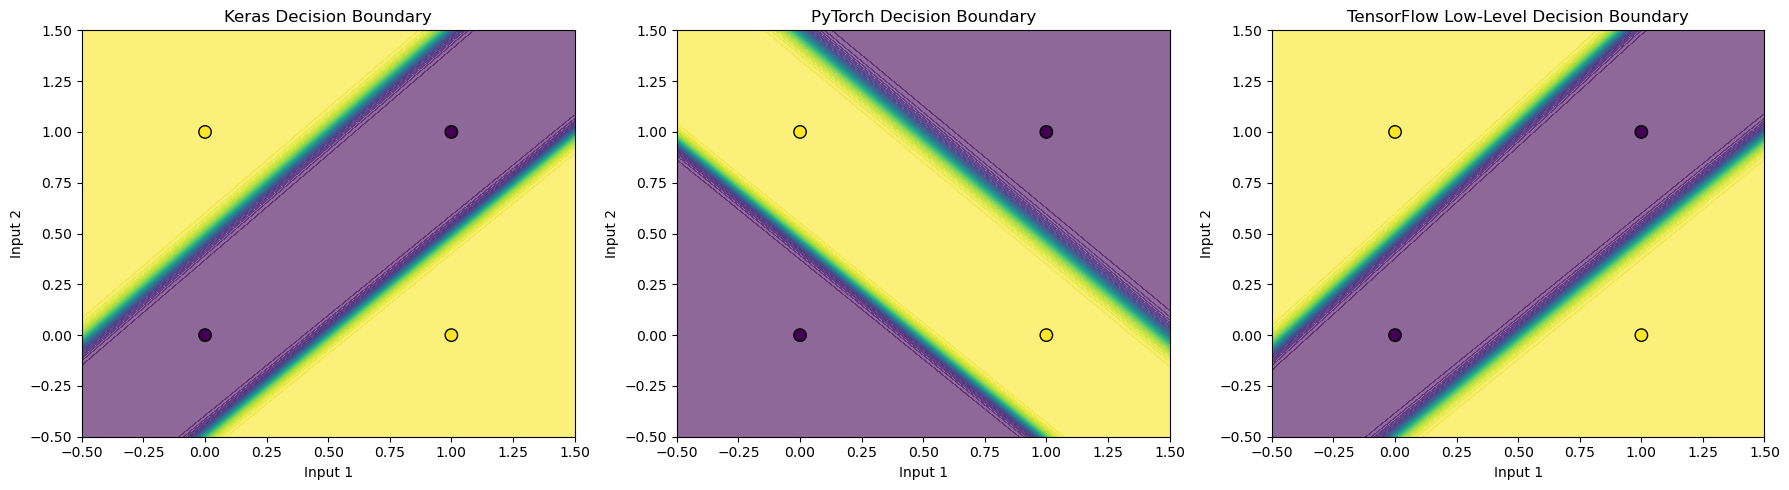

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_db_subplot(ax, predict_fn, X, y, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=50, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolors='k', s=80)
    ax.set_title(title)
    ax.set_xlabel("Input 1")
    ax.set_ylabel("Input 2")

# Keras
plot_db_subplot(
    axes[0],
    lambda g: model_keras.predict(g, verbose=0),
    X, y,
    "Keras Decision Boundary"
)

# PyTorch
plot_db_subplot(
    axes[1],
    lambda g: model_torch(torch.tensor(g, dtype=torch.float32)).detach().numpy(),
    X, y,
    "PyTorch Decision Boundary"
)

# TensorFlow Low-Level
plot_db_subplot(
    axes[2],
    lambda g: forward(tf.convert_to_tensor(g, dtype=tf.float32)).numpy(),
    X, y,
    "TensorFlow Low-Level Decision Boundary"
)

plt.tight_layout()
plt.show()


### Visualisation for Training Loss Curves:

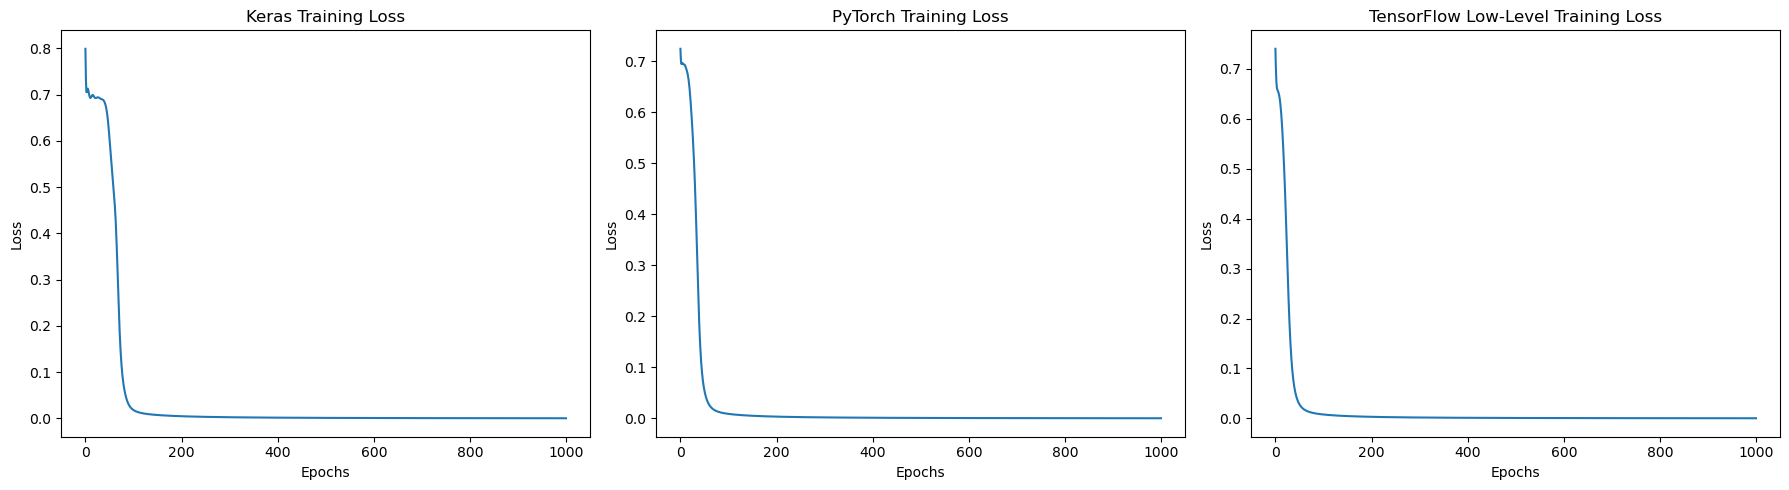

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_keras.history['loss'])
axes[0].set_title("Keras Training Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].plot(losses_torch)
axes[1].set_title("PyTorch Training Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")

axes[2].plot(losses_tf)
axes[2].set_title("TensorFlow Low-Level Training Loss")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Loss")

plt.tight_layout()
plt.show()
